# NLP Project 2 – Fehleranalyse
Whisper large-v1 / v2 / v3 auf STT4SG-350 (Schweizerdeutsch)

---
## Setup & Imports

In [1]:
from helper_functions import *

print('Setup complete.')


Setup complete.


---
## Daten laden

In [2]:
# Alle 3 Modelle in einen DataFrame laden — mit 'version' Spalte
df = load_data()

print("---- Count Samples ----")
print(f"Sample for v1: {len(df[df['version'] == 'v1'])}")       
print(f"Sample for v2: {len(df[df['version'] == 'v2'])}")       
print(f"Sample for v3: {len(df[df['version'] == 'v3'])}")     
print(f'Total Samples: {len(df)}')
print()
CANTONS = sorted(df[COL_CANTON].dropna().unique())

print(f'Versionen:    {df[COL_VERSION].unique().tolist()}')
print()
print("---- Cantons Check----")
for ver in df['version'].unique():
    canton_ver = sorted(df[df['version'] == ver][COL_CANTON].dropna().unique())
    print(f'Cantons in {ver}   ({len(canton_ver)}): {canton_ver}')

print(f'Cantons overall ({len(CANTONS)}): {CANTONS}')

df.head(3)

---- Count Samples ----
Sample for v1: 24605
Sample for v2: 24605
Sample for v3: 24605
Total Samples: 73815

Versionen:    ['v1', 'v2', 'v3']

---- Cantons Check----
Cantons in v1   (16): ['AG', 'BE', 'BL', 'BS', 'GL', 'GR', 'LU', 'SG', 'SH', 'SO', 'TG', 'TI', 'UR', 'VS', 'ZG', 'ZH']
Cantons in v2   (16): ['AG', 'BE', 'BL', 'BS', 'GL', 'GR', 'LU', 'SG', 'SH', 'SO', 'TG', 'TI', 'UR', 'VS', 'ZG', 'ZH']
Cantons in v3   (16): ['AG', 'BE', 'BL', 'BS', 'GL', 'GR', 'LU', 'SG', 'SH', 'SO', 'TG', 'TI', 'UR', 'VS', 'ZG', 'ZH']
Cantons overall (16): ['AG', 'BE', 'BL', 'BS', 'GL', 'GR', 'LU', 'SG', 'SH', 'SO', 'TG', 'TI', 'UR', 'VS', 'ZG', 'ZH']


,path,sentence,canton,model,hypothesis,version
0,8800b4de-fa22-4fdc-9f29-457c4010fd57/d57790928...,"Die Steuerfrage wäre eine andere, die Planung ...",BS,openai/whisper-large,"Die Steuerfragen wären andere, die Planungen a...",v1
1,887b50f8-215b-4a1d-8f32-13516da6506f/73ca6c9b0...,"Ich bin der Meinung, dass ihr noch nicht alle ...",BE,openai/whisper-large,"Ich bin der Meinung, dass Sie noch nicht alle ...",v1
2,31cab952-98eb-45cb-a243-c951519c5c40/3aca44313...,Dann änderte sie ihre Meinung und verlangte di...,LU,openai/whisper-large,Dann hat sie ihre Meinung geändert und den Tuß...,v1


---
## WER Analyse

### Overall

In [3]:
wer_overall = df.groupby(COL_VERSION).apply(compute_wer)
print(wer_overall[['wer', 'substitutions', 'deletions', 'insertions', 'n_samples']].to_string())

# Speichern
wer_overall.to_csv('results/wer_overall.csv')

              wer  substitutions  deletions  insertions  n_samples
version                                                           
v1       0.293622        42764.0     6739.0      7979.0    24605.0
v2       0.256358        37384.0     5839.0      6964.0    24605.0
v3       0.249769        36599.0     5832.0      6466.0    24605.0


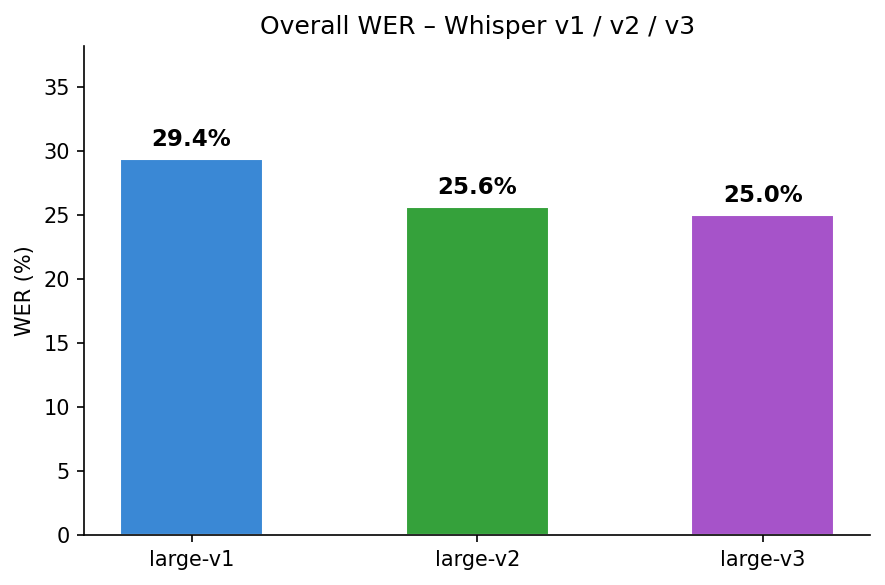

→ figures/fig_wer_overall.png


In [4]:
fig_wer_overall(wer_overall)

### Pro Kanton

In [5]:
wer_by_canton = df.groupby([COL_VERSION, COL_CANTON]).apply(compute_wer)

# Übersicht als Pivot-Tabelle
pivot = wer_by_canton['wer'].unstack(level=0).round(3)
pivot.columns = [V_SHORT[v] for v in pivot.columns]
print(pivot.to_string())

# Speichern
wer_by_canton.to_csv('results/wer_by_canton.csv')

        large-v1  large-v2  large-v3
canton                              
AG         0.259     0.223     0.214
BE         0.346     0.302     0.298
BL         0.348     0.317     0.290
BS         0.298     0.269     0.250
GL         0.281     0.247     0.243
GR         0.266     0.228     0.225
LU         0.250     0.215     0.212
SG         0.287     0.249     0.242
SH         0.187     0.170     0.164
SO         0.334     0.284     0.253
TG         0.277     0.253     0.250
TI         0.203     0.183     0.199
UR         0.218     0.186     0.188
VS         0.379     0.331     0.331
ZG         0.206     0.176     0.177
ZH         0.240     0.206     0.202


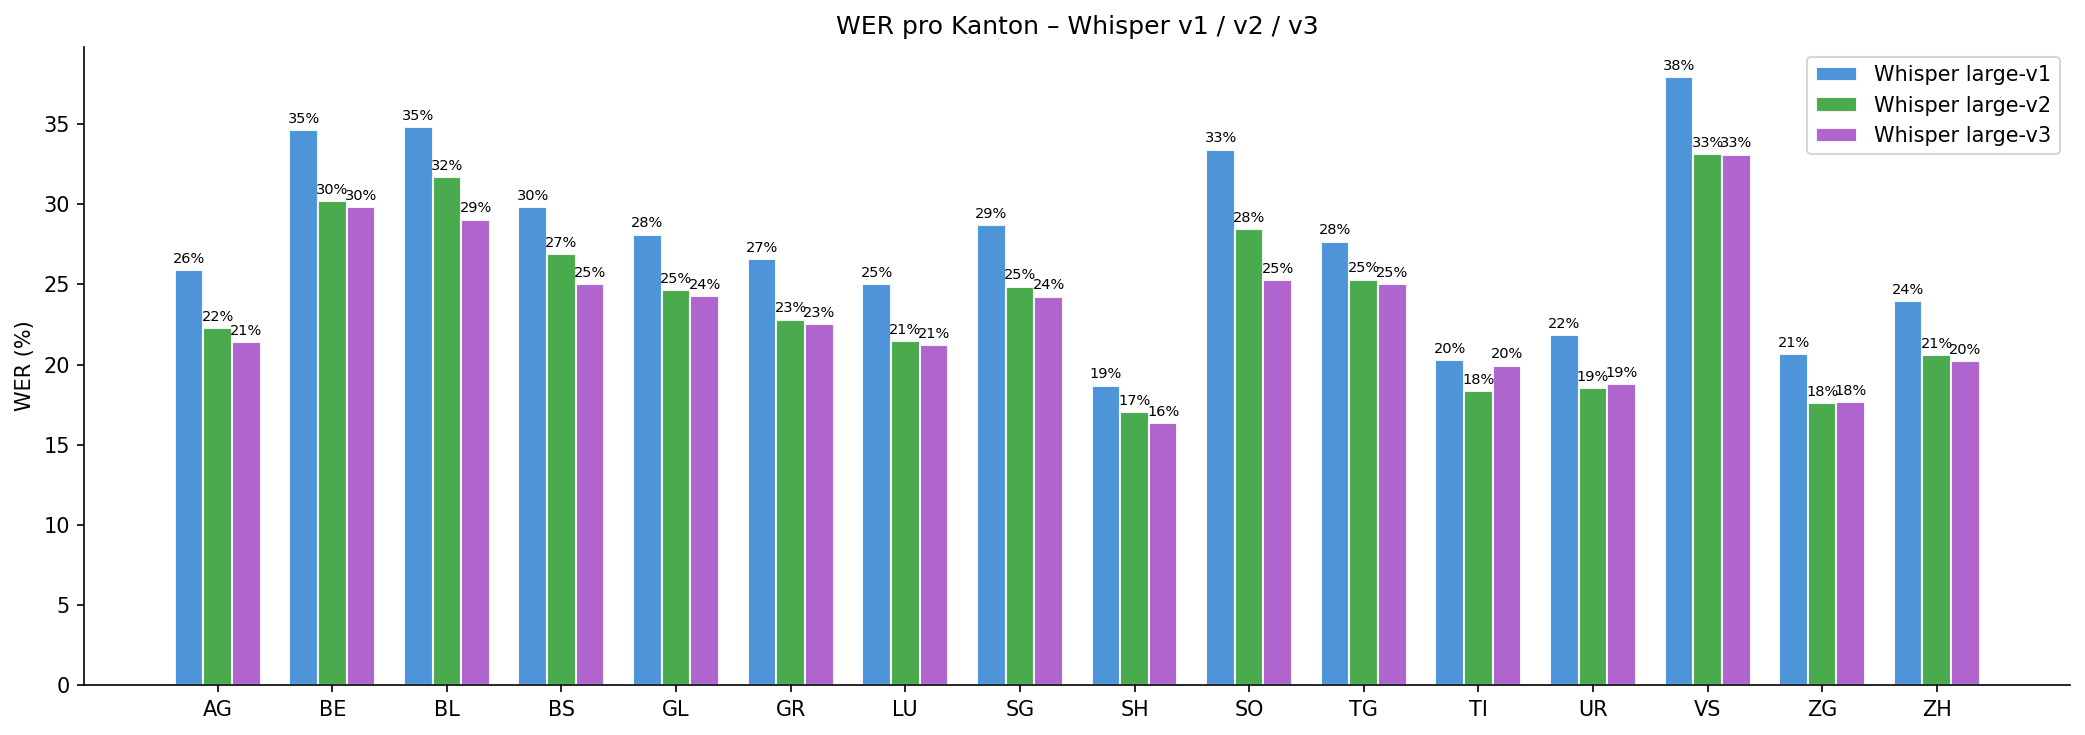

→ figures/fig_wer_by_canton.png


In [6]:
fig_wer_by_canton(wer_by_canton, CANTONS)

### Mit / Ohne Satzzeichen

In [7]:
wer_clean = df.groupby(COL_VERSION).apply(compute_wer_clean)

print('=== WER: Original vs. ohne Satzzeichen ===')
print(f'{"Version":<10} {"WER orig":>10} {"WER clean":>10} {"Differenz":>10}')
print('-' * 45)
for v in VERSIONS:
    orig  = wer_overall.loc[v, 'wer'] * 100
    clean = wer_clean.loc[v, 'wer_clean'] * 100
    print(f'  {V_SHORT[v]:<10} {orig:>9.2f}%  {clean:>9.2f}%  {orig-clean:>+9.2f}%')

=== WER: Original vs. ohne Satzzeichen ===
Version      WER orig  WER clean  Differenz
---------------------------------------------
  large-v1       29.36%      27.56%      +1.80%
  large-v2       25.64%      23.82%      +1.81%
  large-v3       24.98%      23.18%      +1.80%


---
## CER Analyse

### Overall

In [8]:
cer_overall = df.groupby(COL_VERSION).apply(compute_cer)
print('=== Overall CER ===')
print(cer_overall[['cer', 'n_samples']].to_string())

=== Overall CER ===
              cer  n_samples
version                     
v1       0.143201    24605.0
v2       0.125257    24605.0
v3       0.121287    24605.0


### Pro Kanton

In [9]:
cer_by_canton = df.groupby([COL_VERSION, COL_CANTON]).apply(compute_cer)

pivot_cer = cer_by_canton['cer'].unstack(level=0).round(3)
pivot_cer.columns = [V_SHORT[v] for v in pivot_cer.columns]
print(pivot_cer.to_string())

        large-v1  large-v2  large-v3
canton                              
AG         0.124     0.108     0.103
BE         0.181     0.159     0.157
BL         0.164     0.150     0.135
BS         0.137     0.125     0.115
GL         0.137     0.119     0.114
GR         0.132     0.109     0.109
LU         0.121     0.105     0.100
SG         0.136     0.118     0.115
SH         0.091     0.084     0.080
SO         0.164     0.142     0.123
TG         0.153     0.141     0.141
TI         0.098     0.093     0.099
UR         0.100     0.084     0.087
VS         0.184     0.161     0.160
ZG         0.099     0.085     0.085
ZH         0.115     0.100     0.098


### WER vs CER Vergleich

In [10]:
cer_clean = df.groupby(COL_VERSION).apply(compute_cer_clean)

print('=== WER vs CER: Original vs. ohne Satzzeichen ===')
print(f'{"Version":<10} {"WER orig":>10} {"WER clean":>10} {"CER orig":>10} {"CER clean":>10}')
print('-' * 55)
for v in VERSIONS:
    print(f'  {V_SHORT[v]:<10}'
          f'{wer_overall.loc[v, "wer"]*100:>9.2f}% '
          f'{wer_clean.loc[v, "wer_clean"]*100:>9.2f}% '
          f'{cer_overall.loc[v, "cer"]*100:>9.2f}% '
          f'{cer_clean.loc[v, "cer_clean"]*100:>9.2f}%')

=== WER vs CER: Original vs. ohne Satzzeichen ===
Version      WER orig  WER clean   CER orig  CER clean
-------------------------------------------------------
  large-v1      29.36%     27.56%     14.32%     14.37%
  large-v2      25.64%     23.82%     12.53%     12.56%
  large-v3      24.98%     23.18%     12.13%     12.16%


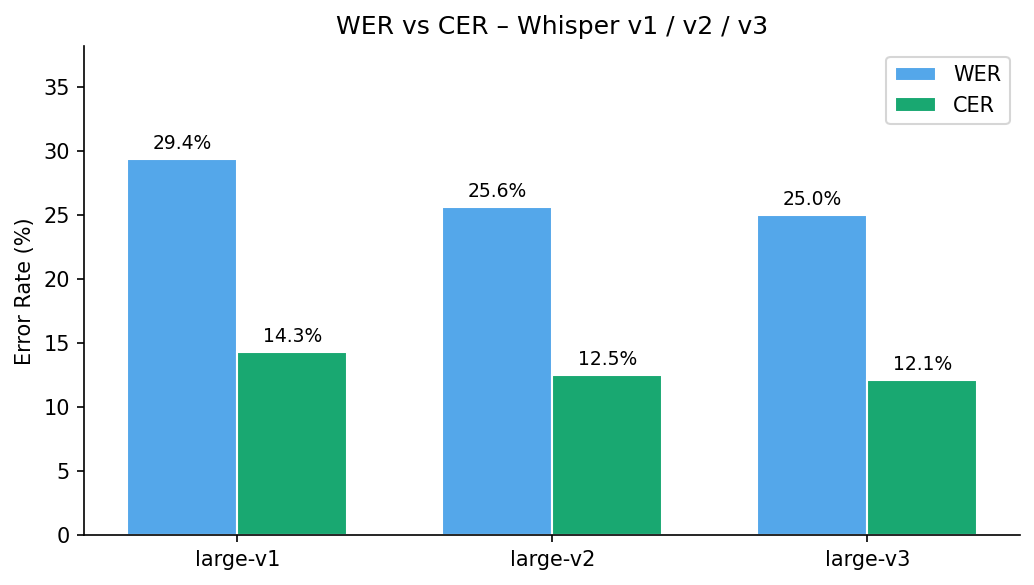

→ figures/fig_wer_vs_cer.png


In [11]:
# Kombinierter DataFrame für Plot
wer_cer = wer_overall[['wer']].join(cer_overall[['cer']])
fig_wer_vs_cer(wer_cer)

---
## Fehlertypen (Sub / Del / Ins)

In [12]:
print('=== Fehlertypen-Verteilung (Overall, Wortebene) ===')
print(f'{"Version":<12} {"Sub%":>8} {"Del%":>8} {"Ins%":>8}')
print('-' * 40)
for v in VERSIONS:
    te = wer_overall.loc[v, 'total_errors']
    s  = wer_overall.loc[v, 'substitutions'] / te * 100
    d  = wer_overall.loc[v, 'deletions']     / te * 100
    i  = wer_overall.loc[v, 'insertions']    / te * 100
    print(f'  {V_SHORT[v]:<12} {s:>7.1f}% {d:>7.1f}% {i:>7.1f}%')

=== Fehlertypen-Verteilung (Overall, Wortebene) ===
Version          Sub%     Del%     Ins%
----------------------------------------
  large-v1        74.4%    11.7%    13.9%
  large-v2        74.5%    11.6%    13.9%
  large-v3        74.8%    11.9%    13.2%


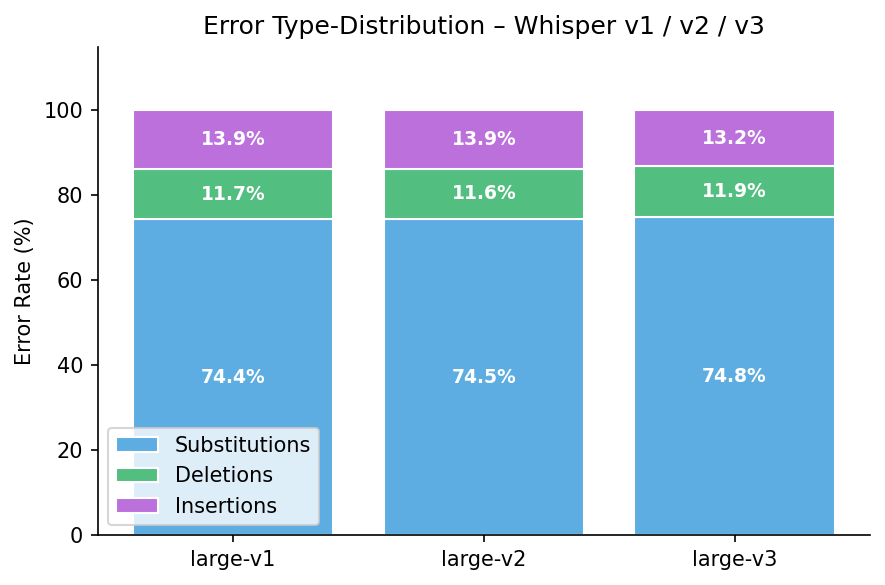

→ figures/fig_error_types.png


In [13]:
fig_error_types(wer_overall)

---
## Qualitative Analyse

⚠️ Die folgenden Zellen brauchen etwas Zeit (~2-3 Min pro Modell).

### Top Substitutionen

In [14]:
for v in VERSIONS:
    print(f'\n=== Top-20 Substitutionen – Whisper {v} ===')
    print(f'{"Ground Truth":<30} → {"Whisper Output":<30} {"N":>5}')
    print('-' * 68)
    for (rw, hw), cnt in get_top_substitutions(df[df[COL_VERSION] == v], top_n=20):
        print(f'{rw:<30} → {hw:<30} {cnt:>5}')


=== Top-20 Substitutionen – Whisper v1 ===
Ground Truth                   → Whisper Output                     N
--------------------------------------------------------------------
diese                          → die                              207
dies                           → das                              191
dieses                         → das                              106
nun                            → jetzt                            102
dieser                         → der                               98
die                            → diese                             95
wurden                         → sind                              87
war                            → ist                               75
den                            → der                               74
hatte                          → hat                               73
wurde                          → ist                               71
deshalb                        → darum         

### Satzzeichen-Fehler

In [15]:
# Welche Satzzeichen kommen im Dataset vor?
print('=== Satzzeichen im Dataset ===')
for char, count in find_punctuation_in_data(df[df[COL_VERSION] == 'v1']).most_common():
    print(f'  "{char}"  →  {count:>8}x')

=== Satzzeichen im Dataset ===
  "."  →     47654x
  ","  →      5329x
  "-"  →      3346x
  "?"  →      2383x
  "'"  →       502x
  "%"  →       385x
  "!"  →       352x
  ":"  →        42x
  "«"  →        41x
  "»"  →        41x
  "’"  →        35x
  "­"  →        35x
  "§"  →        35x
  "̈"  →        28x
  "$"  →         8x
  "/"  →         7x
  "‹"  →         7x
  "›"  →         7x
  "。"  →         2x
  "&"  →         2x
  "°"  →         2x
  "€"  →         2x
  "–"  →         1x


In [16]:
print('=== Satzzeichen im Dataset ===')
print(f'{"Zeichen":<10} {"REF":>8} {"HYP v1":>8} {"HYP v2":>8} {"HYP v3":>8}')
print('-' * 45)

ref_counts = count_punctuation_in_col(df[df[COL_VERSION] == 'v1'][COL_REFERENCE])
hyp_counts = {
    v: count_punctuation_in_col(df[df[COL_VERSION] == v][COL_HYPOTHESIS])
    for v in VERSIONS
}

all_chars = sorted(ref_counts.keys(), key=lambda c: -ref_counts[c])
for char in all_chars:
    ref = ref_counts.get(char, 0)
    h1  = hyp_counts['v1'].get(char, 0)
    h2  = hyp_counts['v2'].get(char, 0)
    h3  = hyp_counts['v3'].get(char, 0)
    print(f'  "{char}"  {ref:>8}  {h1:>8}  {h2:>8}  {h3:>8}')

=== Satzzeichen im Dataset ===
Zeichen         REF   HYP v1   HYP v2   HYP v3
---------------------------------------------
  "."     23954     23700     23937     23731
  ","      2268      3061      2829      3037
  "-"      1806      1540      1478      1529
  "?"      1246      1137      1095      1207
  "'"       224       278       239       215
  "!"       196       156        90        39
  "%"        63       322       334       322
  ":"        42         0         0         0
  "’"        35         0         0         0
  "«"        35         6        19        56
  "»"        35         6        19        56
  "­"        35         0         0         0
  "̈"        28         0         0         0
  "§"        28         7        16        17
  "/"         7         0         0         0
  "‹"         7         0         0         0
  "›"         7         0         0         0


In [17]:
# Welche Satzzeichen führen zu Fehlern? (nur v1, Muster sind gleich)
print('=== Satzzeichen-Fehler – Whisper v1 ===')
subs, dels, ins = get_punctuation_errors(df[df[COL_VERSION] == 'v1'], top_n=50)

print(f'\n── Substitutionen mit Satzzeichen ──')
print(f'{"Ground Truth":<30} → {"Whisper Output":<30} {"N":>5}')
print('-' * 68)
for (rw, hw), cnt in subs:
    print(f'{rw:<30} → {hw:<30} {cnt:>5}')

print(f'\n── Deletions (Satzzeichen in REF, fehlt in HYP) ──')
for rw, cnt in dels:
    print(f'  "{rw}"  gelöscht  (n={cnt})')

print(f'\n── Insertions (Satzzeichen in HYP, nicht in REF) ──')
for hw, cnt in ins:
    print(f'  "{hw}"  eingefügt  (n={cnt})')

=== Satzzeichen-Fehler – Whisper v1 ===

── Substitutionen mit Satzzeichen ──
Ground Truth                   → Whisper Output                     N
--------------------------------------------------------------------
mio.                           → millionen                         19
festgenommen                   → festgenommen.                     17
begonnen.                      → angefangen.                       15
auf.                           → aufgenommen.                      15
vor.                           → vorgelegt.                        14
erhalten.                      → bekommen.                         13
10                             → 10'000                            12
70                             → 70%                               11
aus.                           → ausgeschieden.                    11
20                             → 20%                               11
schlagzeilen.                  → gesorgt.                          11
informiert.  

### Linguistische Kategorien

In [18]:
for v in VERSIONS:
    print(f'\n{"="*60}')
    print(f'Linguistische Fehlerkategorien – Whisper {v}')
    print(f'{"="*60}')
    cats = categorize_substitutions(df[df[COL_VERSION] == v])
    for cat_name, items in cats.items():
        print(f'\n── {cat_name} ({len(items)} Einträge) ──')
        for ref_w, hyp_w, cnt in items[:8]:
            print(f'  "{ref_w}" → "{hyp_w}"  (n={cnt})')


Linguistische Fehlerkategorien – Whisper v1

── Zahlen (4 Einträge) ──
  "zehn" → "10"  (n=21)
  "fünf" → "5"  (n=12)
  "zwei" → "2"  (n=12)
  "tausend" → "1000"  (n=9)

── Eigennamen (0 Einträge) ──

── Zerstückelt (0 Einträge) ──

── Sonstige (196 Einträge) ──
  "diese" → "die"  (n=207)
  "dies" → "das"  (n=191)
  "dieses" → "das"  (n=106)
  "nun" → "jetzt"  (n=102)
  "dieser" → "der"  (n=98)
  "die" → "diese"  (n=95)
  "wurden" → "sind"  (n=87)
  "war" → "ist"  (n=75)

Linguistische Fehlerkategorien – Whisper v2

── Zahlen (5 Einträge) ──
  "zehn" → "10"  (n=26)
  "fünf" → "5"  (n=18)
  "tausend" → "1000"  (n=11)
  "quadratmeter" → "m2"  (n=10)
  "vier" → "4"  (n=9)

── Eigennamen (0 Einträge) ──

── Zerstückelt (0 Einträge) ──

── Sonstige (195 Einträge) ──
  "dies" → "das"  (n=196)
  "diese" → "die"  (n=184)
  "die" → "diese"  (n=140)
  "wurden" → "sind"  (n=110)
  "dieses" → "das"  (n=106)
  "nun" → "jetzt"  (n=105)
  "deshalb" → "darum"  (n=86)
  "den" → "der"  (n=86)

Linguist

Extrahiere Top-10 Fehler-Token pro Typ ...
  Extrahiere v1 (24,605 rows) ... done
  Extrahiere v2 (24,605 rows) ... done
  Extrahiere v3 (24,605 rows) ... done


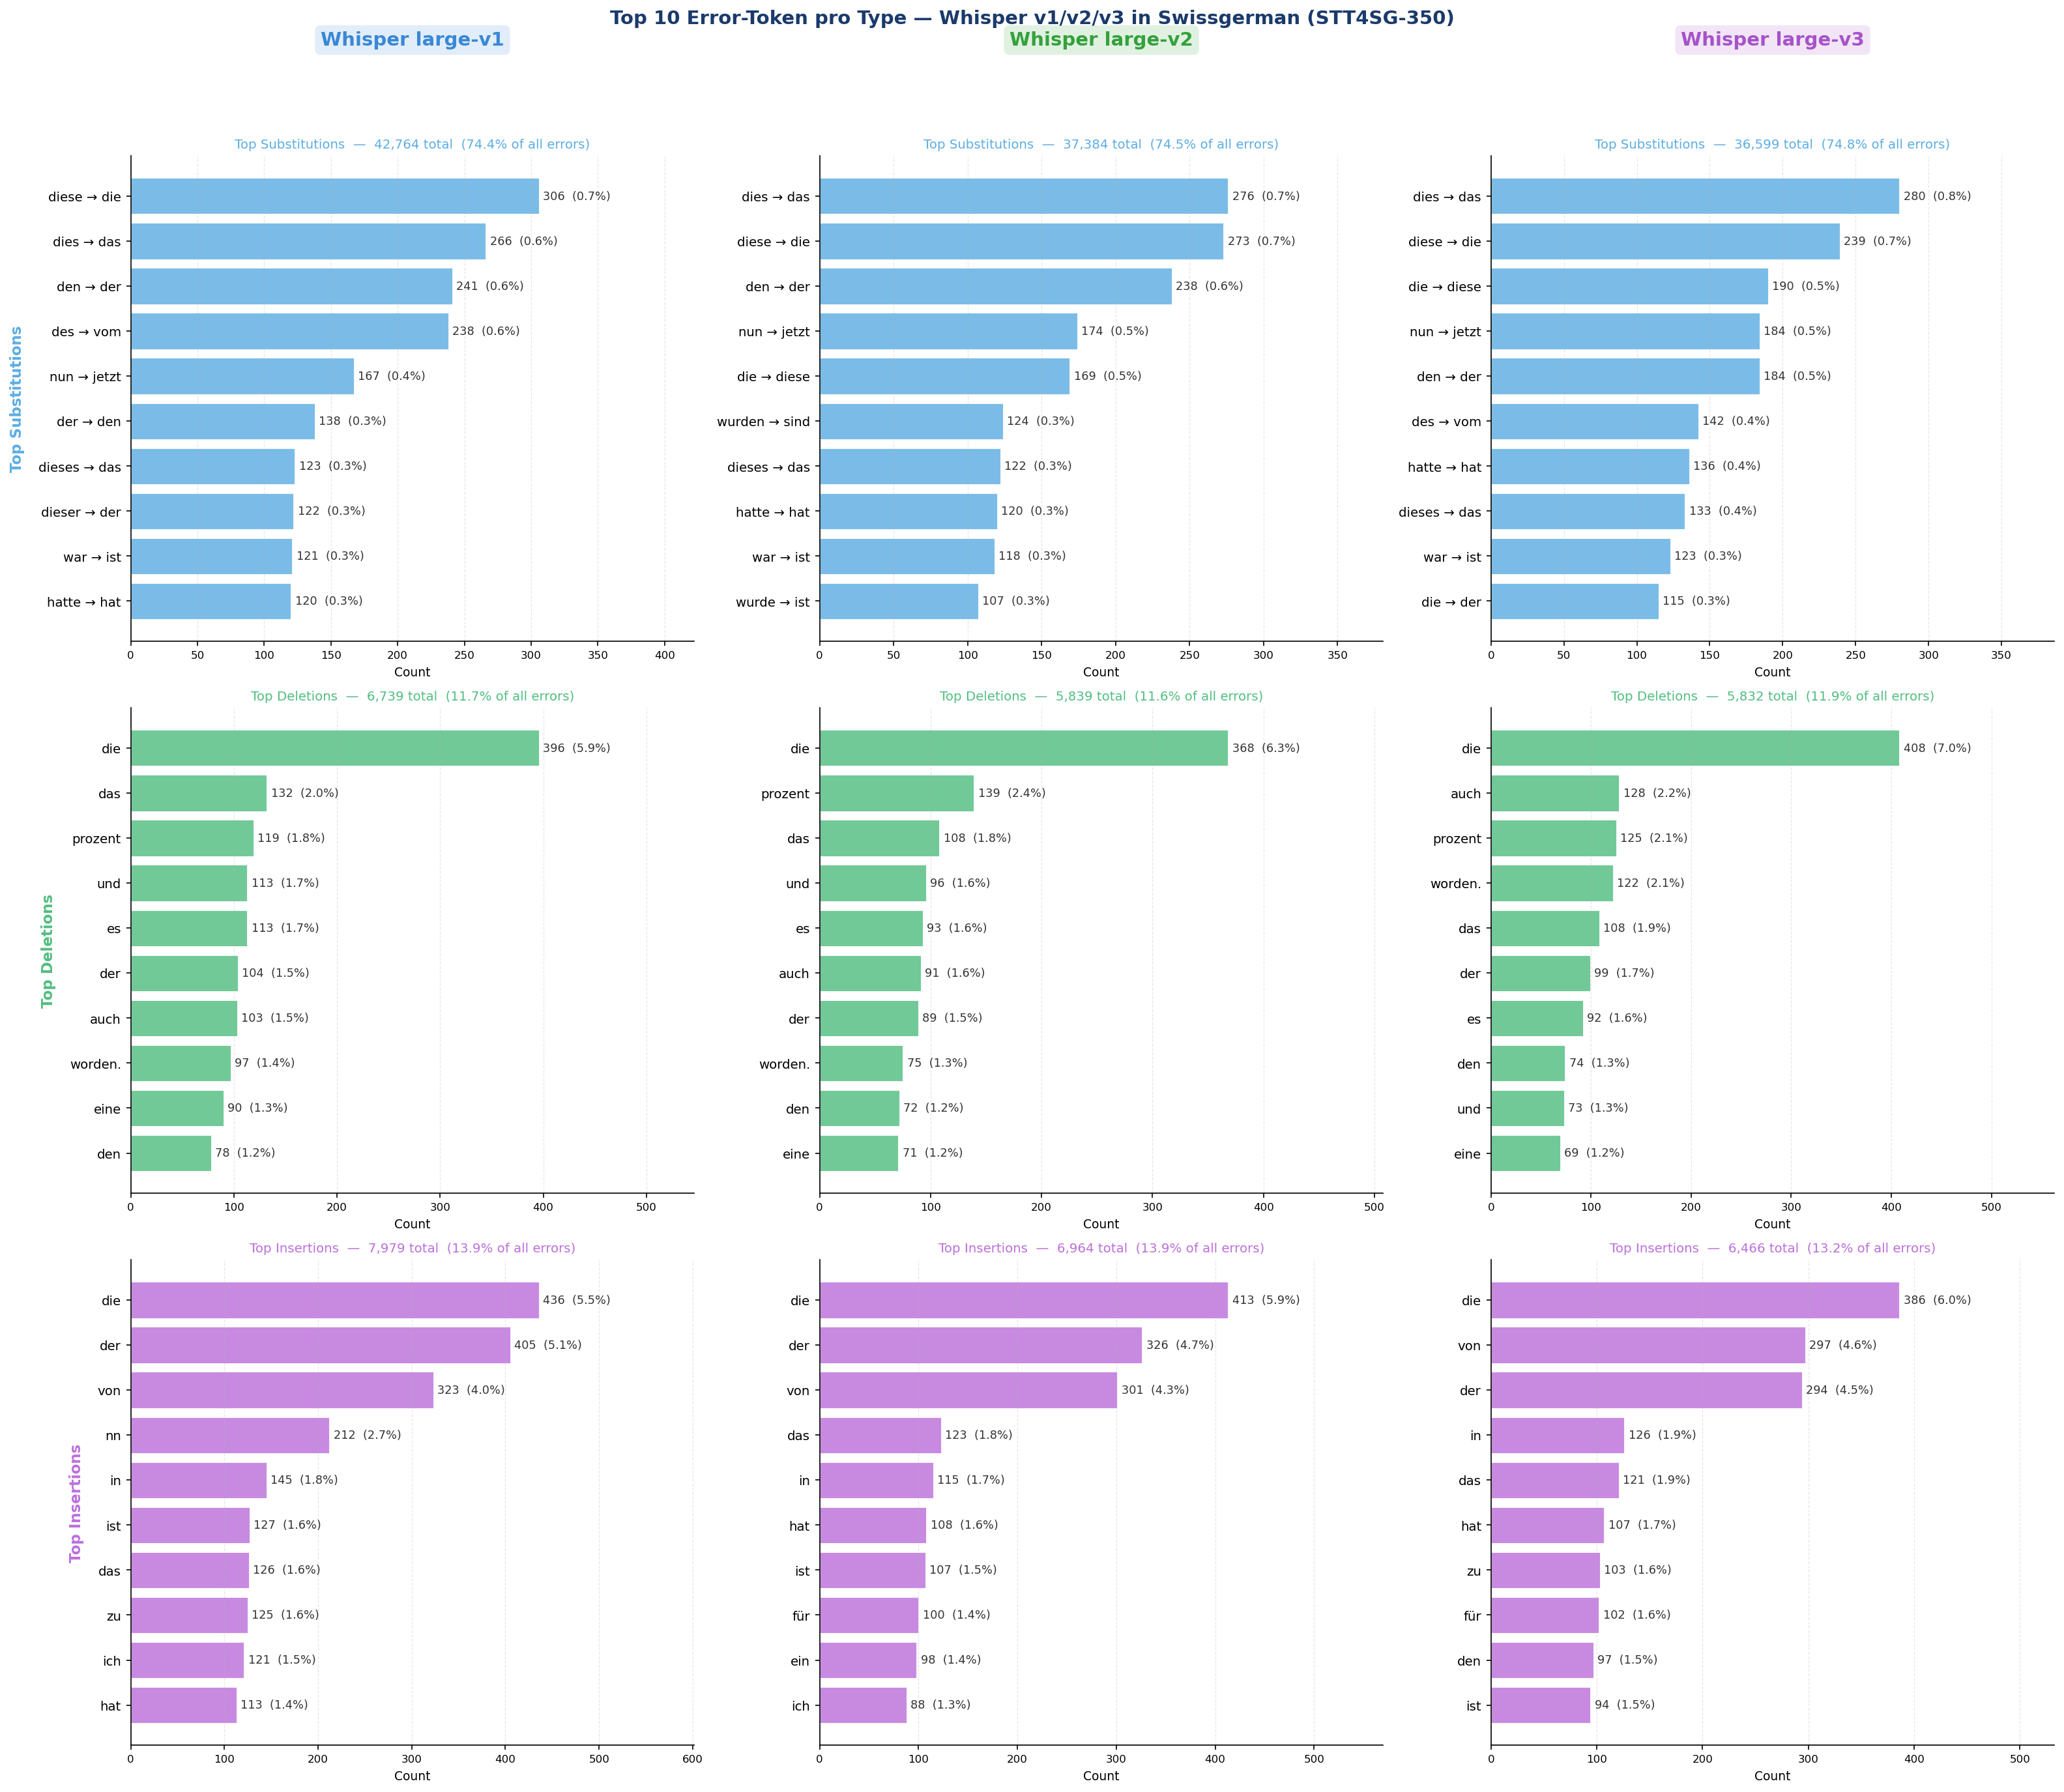

→ figures/fig_error_top10.png


In [19]:
# ⚠️ Dauert ~2-3 Min (analysiert jede Row einzeln)
print("Extrahiere Top-10 Fehler-Token pro Typ ...")
fig_error_top10(df, top_n=10)

Extrahiere Top-10 Fehler-Token (dauert ~2-3 Min) ...
  Extrahiere v1 (24,605 rows) ... 

done
  Extrahiere v2 (24,605 rows) ... done
  Extrahiere v3 (24,605 rows) ... done


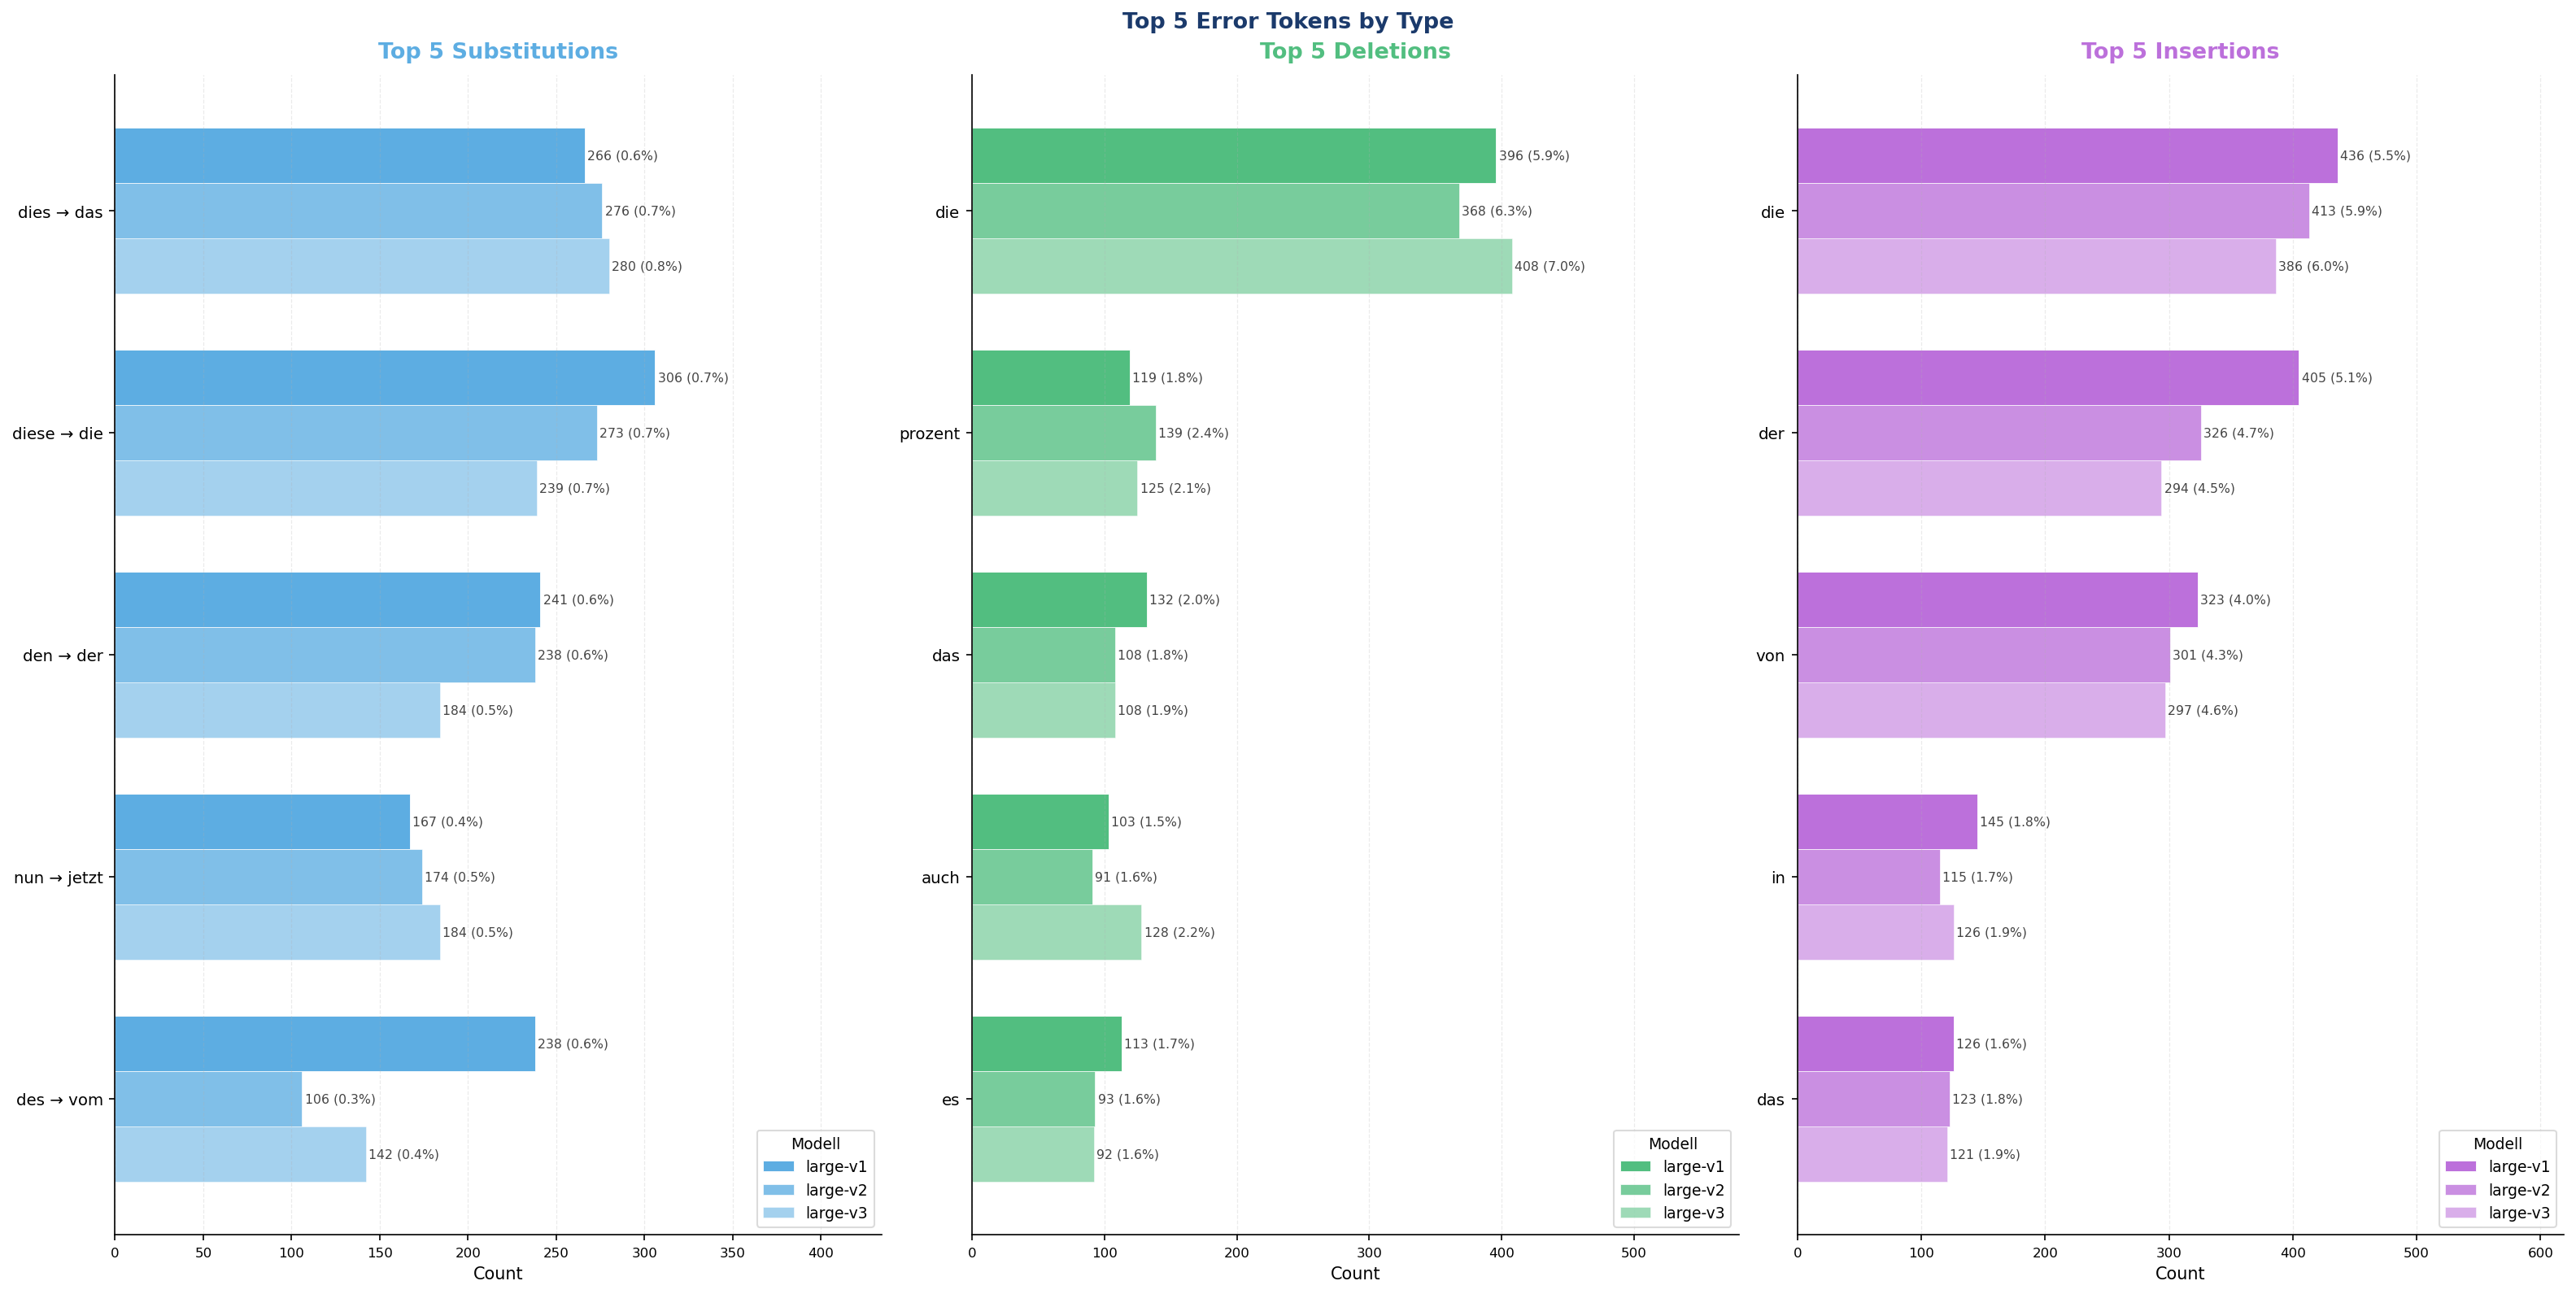

→ figures/fig_error_top10_grouped.png


In [20]:
print("Extrahiere Top-10 Fehler-Token (dauert ~2-3 Min) ...")
fig_error_top10_grouped(df, top_n=5)

  Extrahiere v1 (24,605 rows) ... 

done
  Extrahiere v2 (24,605 rows) ... done
  Extrahiere v3 (24,605 rows) ... done


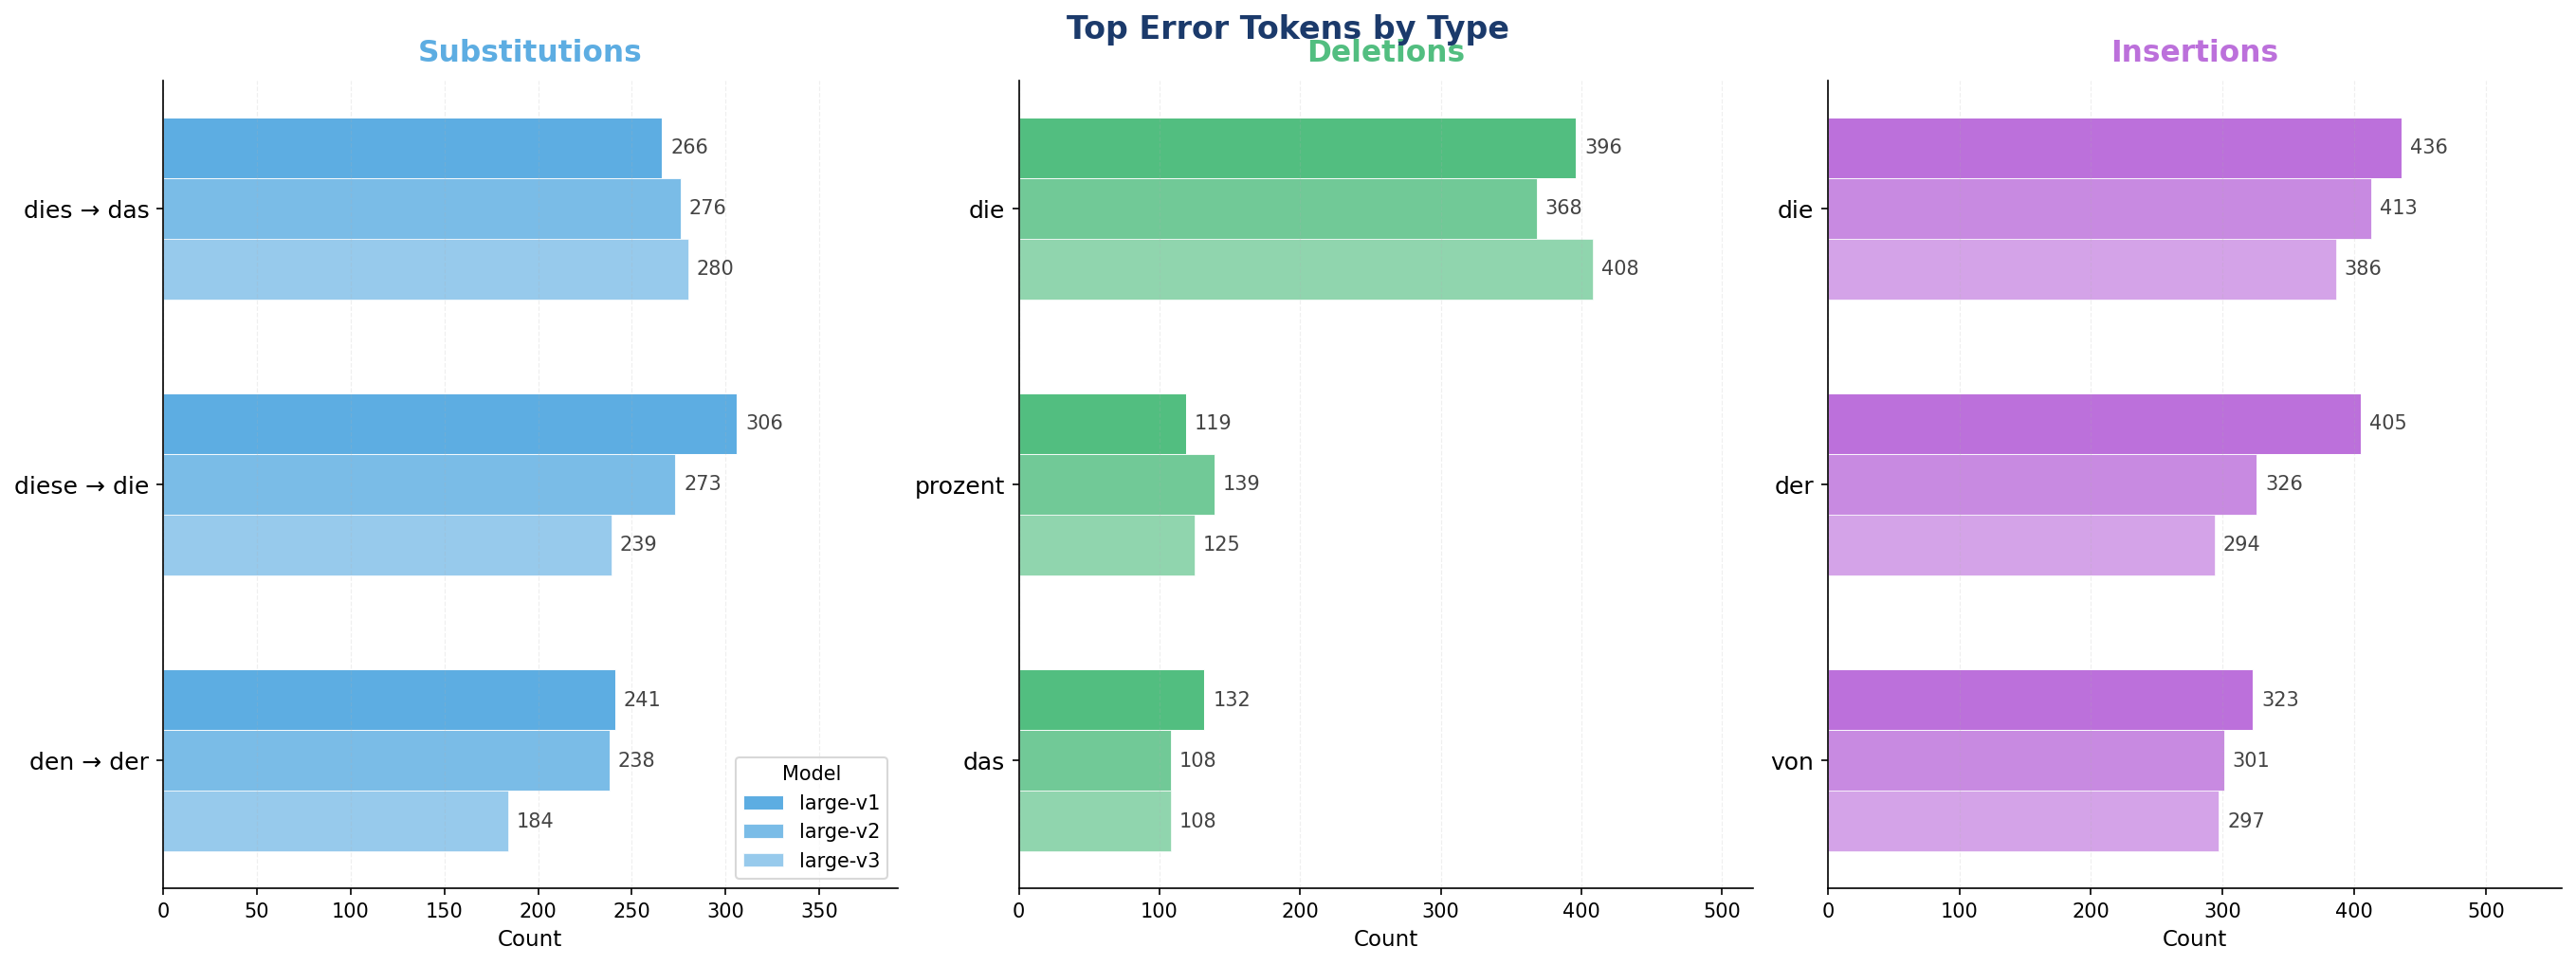

→ figures/fig_error_top3_grouped_poster.png


In [21]:
fig_error_top3_grouped_poster(df)

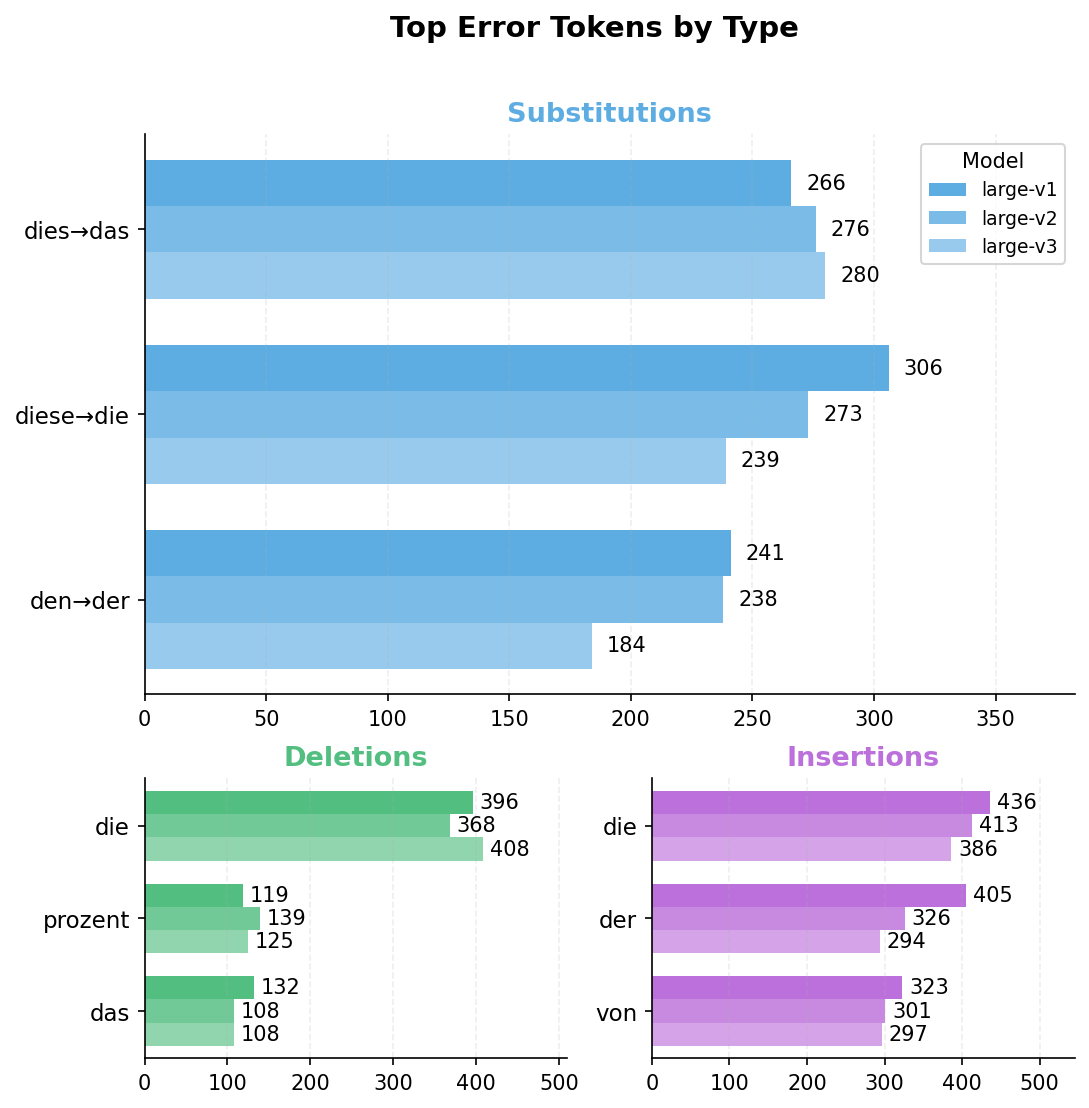

In [22]:
fig_error_top3_focus_sub(df)

In [23]:
pct, examples = analyze_semantic_substitutions_fast(df)



Similar substitutions: 42419/116747 (36.33%)

Examples:
steuerfrage → steuerfragen
wäre → wären
planung → planungen
habt. → haben.
neue → neuen
syrer → säurer
soll → sollte
wir → wie
gut. → gut?
alters → alter


In [24]:
def get_error_examples_with_wer(df, n=10):
    examples = []

    for _, row in df.iterrows():
        ref = safe_str(row[COL_REFERENCE])
        hyp = safe_str(row[COL_HYPOTHESIS])

        if not ref or not hyp:
            continue

        if ref != hyp:
            try:
                out = process_words([ref], [hyp])
                wer = out.wer
                subs = out.substitutions
                dels = out.deletions
                ins  = out.insertions
            except:
                continue

            examples.append({
                "ref": ref,
                "hyp": hyp,
                "wer": wer,
                "sub": subs,
                "del": dels,
                "ins": ins
            })

        if len(examples) >= n:
            break

    return examples


examples = get_error_examples_with_wer(df, n=5)

for e in examples:
    print(f"GT:  {e['ref']}")
    print(f"PR:  {e['hyp']}")
    print(f"WER: {e['wer']:.2f} | S:{e['sub']} D:{e['del']} I:{e['ins']}")
    print("-"*50)

GT:  die steuerfrage wäre eine andere, die planung eine nachhaltigere.
PR:  die steuerfragen wären andere, die planungen auch haltiger.
WER: 0.67 | S:5 D:1 I:0
--------------------------------------------------
GT:  ich bin der meinung, dass ihr noch nicht alle sparmöglichkeiten ausgeschöpft habt.
PR:  ich bin der meinung, dass sie noch nicht alle sparmöglichkeiten ausgeschöpft haben.
WER: 0.17 | S:2 D:0 I:0
--------------------------------------------------
GT:  dann änderte sie ihre meinung und verlangte die tausender zurück.
PR:  dann hat sie ihre meinung geändert und den tußiger zurückverlangt.
WER: 0.60 | S:4 D:1 I:1
--------------------------------------------------
GT:  und neue türen haben sich nicht geöffnet.
PR:  die neuen türen haben sich nicht geöffnet.
WER: 0.29 | S:2 D:0 I:0
--------------------------------------------------
GT:  der gemeinderat nimmt es auch als postulat entgegen.
PR:  der gemeintod nimmt sauers postulat entgegen.
WER: 0.50 | S:2 D:2 I:0
----------------

In [25]:
queries = [
    "kino",
    "idee",
    "geöffnet",
    "%",
    "das",
    "Prozent"
]


for q in queries:
    match = df[
        df["sentence"].apply(lambda x: safe_str(x)).str.contains(safe_str(q))
    ]

    if len(match) > 0:
        row = match.iloc[0]
        out = process_words([safe_str(row["sentence"])], [safe_str(row["hypothesis"])])

        print("\n---")
        print("Query:", q)
        print("GT: ", row["sentence"])
        print("PR: ", row["hypothesis"])
        print("WER:", round(out.wer, 2))
    else:
        print("\n---")
        print(q, "→ NOT FOUND")


---
kino → NOT FOUND

---
Query: idee
GT:  Möglicherweise entstehen dadurch ganz neue Ideen.
PR:  Möglicherweise entstehen dadurch ganz neue Ideen.
WER: 0.0

---
Query: geöffnet
GT:  Und neue Türen haben sich nicht geöffnet.
PR:  Die neuen Türen haben sich nicht geöffnet.
WER: 0.29

---
Query: %
GT:  Ein 30%iges Wachstum im Jahr 2018 gegenüber dem Schnitt 2014-2017 ist inakzeptabel.
PR:  Ein 30% Wachstum im Jahr 2018 gegenüber dem Schnitt von 2014 bis 2017 ist inakzeptabel.
WER: 0.42

---
Query: das
GT:  Ich bin der Meinung, dass ihr noch nicht alle Sparmöglichkeiten ausgeschöpft habt.
PR:  Ich bin der Meinung, dass Sie noch nicht alle Sparmöglichkeiten ausgeschöpft haben.
WER: 0.17

---
Query: Prozent
GT:  Über alle Banken hinweg betrug das Plus 2,7 Prozent.
PR:  Über alle Banken hinweg war es plus 2,7 Prozent.
WER: 0.22


In [26]:
def get_substitution_examples(df, n=10):
    examples = []

    for _, row in df.iterrows():
        ref = safe_str(row[COL_REFERENCE])
        hyp = safe_str(row[COL_HYPOTHESIS])

        if not ref or not hyp:
            continue

        try:
            out = process_words([ref], [hyp])
        except:
            continue

        rw_all = ref.split()
        hw_all = hyp.split()

        for chunk in out.alignments[0]:
            if chunk.type == "substitute":
                rw = " ".join(rw_all[chunk.ref_start_idx:chunk.ref_end_idx])
                hw = " ".join(hw_all[chunk.hyp_start_idx:chunk.hyp_end_idx])

                examples.append((rw, hw))

                if len(examples) >= n:
                    return examples

    return examples



examples = get_substitution_examples(df, n=5)

for r, h in examples:
    print(f"{r} → {h}")

steuerfrage wäre → steuerfragen wären
planung eine nachhaltigere. → planungen auch haltiger.
ihr → sie
habt. → haben.
änderte → hat


---
## Zusammenfassung

In [27]:
print('=' * 60)
print('ZUSAMMENFASSUNG')
print('=' * 60)
for v in VERSIONS:
    r     = wer_overall.loc[v]
    best  = wer_by_canton.loc[v, 'wer'].idxmin()
    worst = wer_by_canton.loc[v, 'wer'].idxmax()
    print(f'\nWhisper {V_SHORT[v]}:')
    print(f'  WER: {r["wer"]*100:.2f}%  |  CER: {cer_overall.loc[v, "cer"]*100:.2f}%')
    print(f'  Fehler: Sub={int(r["substitutions"])}  Del={int(r["deletions"])}  Ins={int(r["insertions"])}')
    print(f'  Bester Kanton:        {best}  (WER={wer_by_canton.loc[(v, best), "wer"]*100:.1f}%)')
    print(f'  Schlechtester Kanton: {worst} (WER={wer_by_canton.loc[(v, worst), "wer"]*100:.1f}%)')

print('\nGenerierte Figures:')
for f in sorted(os.listdir('figures')):
    if f.endswith('.png'):
        print(f'  figures/{f}')

ZUSAMMENFASSUNG

Whisper large-v1:
  WER: 29.36%  |  CER: 14.32%
  Fehler: Sub=42764  Del=6739  Ins=7979
  Bester Kanton:        SH  (WER=18.7%)
  Schlechtester Kanton: VS (WER=37.9%)

Whisper large-v2:
  WER: 25.64%  |  CER: 12.53%
  Fehler: Sub=37384  Del=5839  Ins=6964
  Bester Kanton:        SH  (WER=17.0%)
  Schlechtester Kanton: VS (WER=33.1%)

Whisper large-v3:
  WER: 24.98%  |  CER: 12.13%
  Fehler: Sub=36599  Del=5832  Ins=6466
  Bester Kanton:        SH  (WER=16.4%)
  Schlechtester Kanton: VS (WER=33.1%)

Generierte Figures:
  figures/fig_error_top10.png
  figures/fig_error_top10_grouped.png
  figures/fig_error_top3_focus_sub.png
  figures/fig_error_top3_grouped_poster.png
  figures/fig_error_top3_vertical.png
  figures/fig_error_types.png
  figures/fig_wer_by_canton.png
  figures/fig_wer_overall.png
  figures/fig_wer_vs_cer.png
